<a href="https://colab.research.google.com/github/Tejaswimadastu/Deep_Learning/blob/main/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍 Scenario: Fashion Product Image Classifier
You are working as an AI Engineer for an e-commerce company.
The company wants to automatically classify clothing products from images into categories such as:
T-shirt
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot
The dataset contains 28×28 grayscale images of fashion items.
Your goal is to build a Convolutional Neural Network (CNN) that can classify these fashion products correctly.

Task 1 — Dataset Exploration
Load the Fashion-MNIST dataset and perform basic inspection.
Students must:
Load dataset using TensorFlow/Keras
Print:
Number of training images
Number of testing images
Display 10 random images with their labels
Goal:

Understand the dataset visually.
Task 2 — Data Preprocessing
Prepare the dataset for CNN training.
Students must:
Normalize pixel values (0–255 → 0–1)
Reshape images to CNN format
Expected shape:
(28, 28, 1)
Also convert labels to one-hot encoding.

Task 3 — Visualize Class Distribution
Students must:
Count number of images in each class
Plot bar chart of class distribution
Goal:

Check whether the dataset is balanced.


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Data Exploration

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Number of training images:", X_train.shape[0])
print("Number of testing images:", X_test.shape[0])

Number of training images: 60000
Number of testing images: 10000


In [4]:
class_names = [
'T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

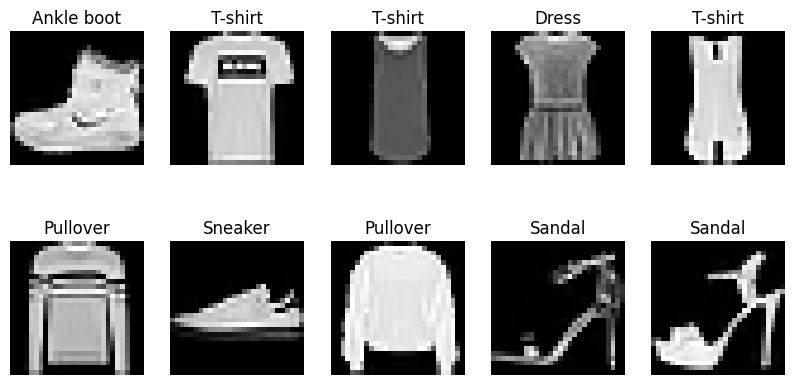

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

# Data Preprocessing

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [8]:
# One hot Encoding
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Vizualize class Distribution

In [9]:
class_counts = np.sum(y_train, axis=0)

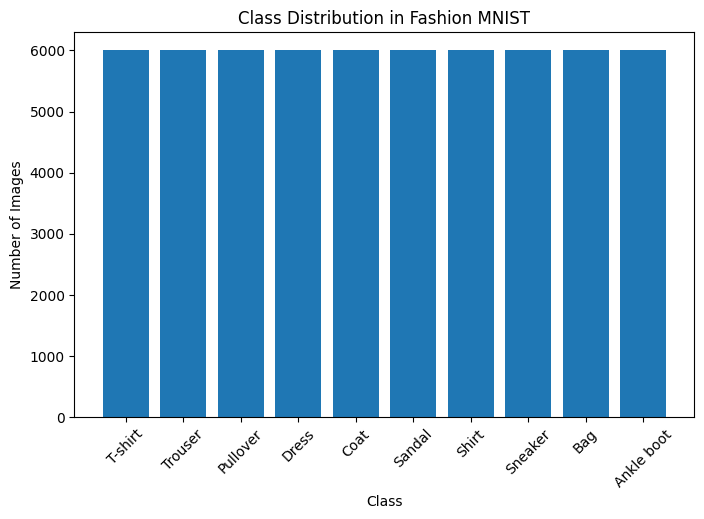

In [10]:
plt.figure(figsize=(8,5))
plt.bar(class_names, class_counts)

plt.xticks(rotation=45)
plt.title("Class Distribution in Fashion MNIST")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

# Building CNN Model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.7782 - loss: 0.6193 - val_accuracy: 0.8765 - val_loss: 0.3374
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.8849 - loss: 0.3127 - val_accuracy: 0.8938 - val_loss: 0.2982
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9038 - loss: 0.2624 - val_accuracy: 0.8936 - val_loss: 0.2885
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9173 - loss: 0.2240 - val_accuracy: 0.8902 - val_loss: 0.3023
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9257 - loss: 0.1954 - val_accuracy: 0.8972 - val_loss: 0.2786
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9360 - loss: 0.1694 - val_accuracy: 0.9016 - val_loss: 0.2802
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9442 - loss: 0.1492 - val_accuracy: 0.9129 - val_loss: 0.2518
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9505 -

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9102 - loss: 0.2890
Test Accuracy: 0.9124000072479248


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


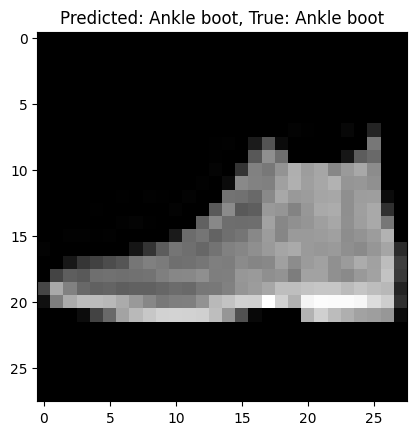

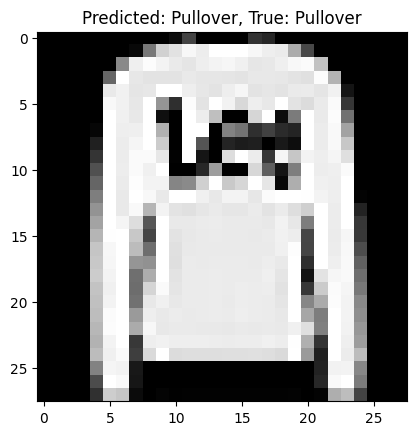

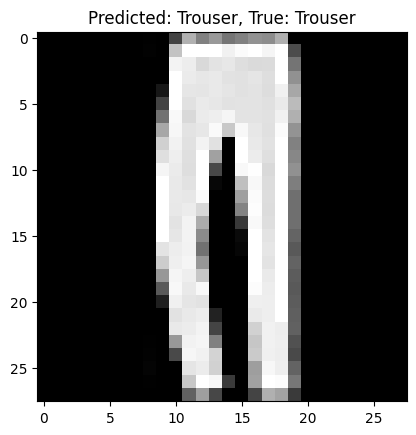

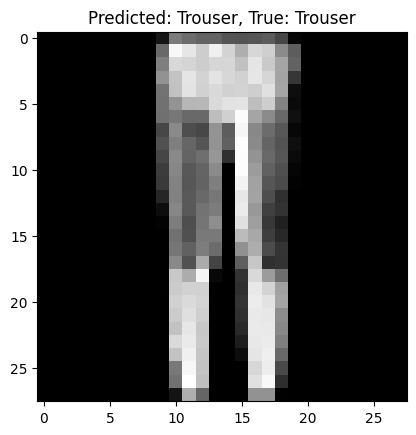

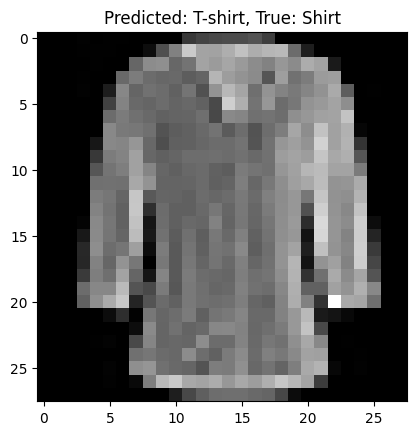

In [16]:
predictions = model.predict(X_test[:5])

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:5], axis=1)

for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {class_names[predicted_classes[i]]}, True: {class_names[true_classes[i]]}")
    plt.show()

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

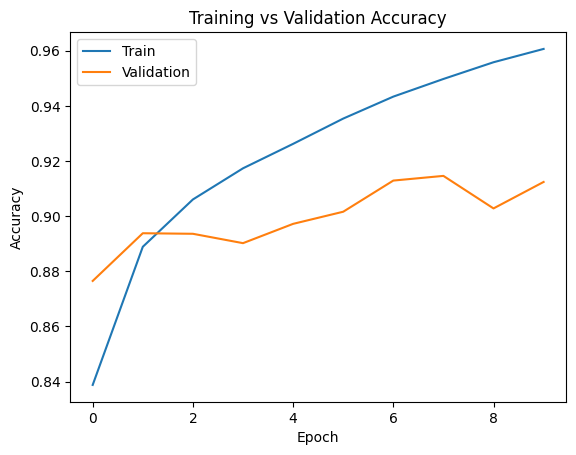

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])

plt.show()

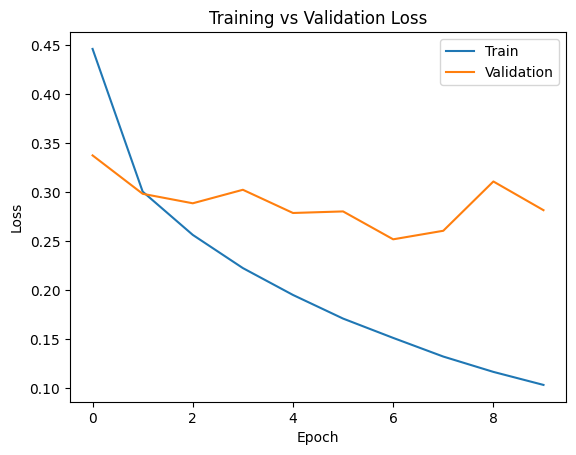

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])

plt.show()

In [21]:
from tensorflow.keras.layers import Dropout

model2 = Sequential([

Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
Conv2D(32,(3,3),activation='relu'),
MaxPooling2D((2,2)),

Conv2D(64,(3,3),activation='relu'),
MaxPooling2D((2,2)),

Flatten(),

Dense(128,activation='relu'),
Dropout(0.5),

Dense(10,activation='softmax')

])

In [22]:
model2.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [23]:
history2 = model2.fit(
X_train,
y_train,
epochs=10,
batch_size=64,
validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.6869 - loss: 0.8633 - val_accuracy: 0.8654 - val_loss: 0.3696
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.8533 - loss: 0.4047 - val_accuracy: 0.8859 - val_loss: 0.3172
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 58s 78ms/step - accuracy: 0.8807 - loss: 0.3355 - val_accuracy: 0.8982 - val_loss: 0.2682
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 54s 72ms/step - accuracy: 0.8951 - loss: 0.2921 - val_accuracy: 0.9069 - val_loss: 0.2477
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.9029 - loss: 0.2663 - val_accuracy: 0.9125 - val_loss: 0.2402
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.9125 - loss: 0.2448 - val_accuracy: 0.9153 - val_loss: 0.2273
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.9205 - loss: 0.2193 - val_accuracy: 0.9197 - val_loss: 0.2192
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 74ms/step - accuracy: 0.9232 - loss: 0.2115 - 

In [24]:
test_loss2, test_acc2 = model2.evaluate(X_test, y_test)

print("Improved Model Accuracy:", test_acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9175 - loss: 0.2479
Improved Model Accuracy: 0.9172999858856201


In [25]:
print("Model 1 Accuracy:", test_acc)
print("Model 2 Accuracy:", test_acc2)

Model 1 Accuracy: 0.9124000072479248
Model 2 Accuracy: 0.9172999858856201
